# 03 - NDNsim anomaly detection (Isolation Forest)

Unsupervised **Isolation Forest** detection of Interest Flooding (IFA) and Cache
Pollution (CP) on ns-3 / ndnSIM tracer telemetry. This is the **same method and
house style as the miniNDN track** (`StandardScaler -> IsolationForest`,
`n_estimators=200`, `contamination=0.01`, scores normalized to 0-100), so both
tracks of the study use one unified detector.

**Unsupervised:** the forest is fit on **normal-scenario traffic only** (first
200 s). The per-second attack labels in the data are used **for evaluation only**
(detection rate, latency, FPR), never for fitting.

**Score convention.** We map the Isolation Forest `decision_function` (positive =
normal) to a normalized `[0, 100]` score and report `anomaly_score = 100 - norm`,
so **higher = more anomalous**; the alarm fires at `anomaly_score >= 70` (the
equivalent of the miniNDN normalized boundary).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 150, "font.size": 9})

PROJECT_ROOT  = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "processed"
FIG_DIR       = PROJECT_ROOT / "figures" / "detection"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TOPOLOGIES = ["dfn", "dumbbell", "tree"]
SCENARIOS  = ["normal", "ifa", "cp"]
SCENARIO_COLORS = {"normal": "#4c72b0", "ifa": "#c44e52", "cp": "#dd8452"}
ROLE_COLORS     = {"router": "#dd8452", "consumer": "#4c72b0"}

# Engineered face/cache counters + ratios (no PIT in ndnSIM tracers)
FEATURES = ["InInterests", "OutInterests", "InData", "cache_hit_ratio",
            "satisfaction_ratio", "timeout_ratio", "nack_ratio",
            "interest_amp", "data_ratio"]

BASELINE_WINDOW = 200   # seconds of normal traffic used to fit the forest
ATTACK_START    = 301   # attacks injected at t = 300 s
ALARM           = 70    # anomaly_score >= 70  <=>  miniNDN normalized score < 30
SEED            = 42

# Ground-truth attacker nodes (global node IDs from .cpp creation order,
# cross-checked vs InInterests during attack). EVALUATION ONLY - not used in fitting.
#   tree/dfn: producers 0,1 | routers 2..5 | consumers 6..11  -> c1=6, c6=11
#   dumbbell: consumers 0,1,2 ...                              -> c1=0, c3=2
ATTACKER_NODES = {
    ("tree", "ifa"): {6},     ("dfn", "ifa"): {6},     ("dumbbell", "ifa"): {0},
    ("tree", "cp"):  {6, 11}, ("dfn", "cp"):  {6, 11}, ("dumbbell", "cp"):  {0, 2},
}

def normalize(scores, thr, smin, smax):
    # miniNDN-style map: decision_function -> [0,100], high = normal
    scores = np.asarray(scores, float); out = np.empty_like(scores)
    hi = scores >= thr
    dhi = (smax - thr) or 1.0; dlo = (thr - smin) or 1.0
    out[hi]  = 30 + (scores[hi]  - thr) / dhi * 70
    out[~hi] = 30 * (scores[~hi] - smin) / dlo
    return np.clip(out, 0, 100)

print("Config ready.")
print("Features:", FEATURES)
print(f"Alarm: anomaly_score >= {ALARM}   (unsupervised IF, fit on normal <= {BASELINE_WINDOW}s)")

Config ready.
Features: ['InInterests', 'OutInterests', 'InData', 'cache_hit_ratio', 'satisfaction_ratio', 'timeout_ratio', 'nack_ratio', 'interest_amp', 'data_ratio']
Alarm: anomaly_score >= 70   (unsupervised IF, fit on normal <= 200s)


In [2]:
full = pd.read_csv(PROCESSED_DIR / "full_dataset.csv")
print("Full dataset:", full.shape, "| scenarios:", dict(full["scenario"].value_counts()))
for topo in TOPOLOGIES:
    df_t = full[full["topology"] == topo]
    cons = sorted(df_t[df_t["role"] == "consumer"]["Node"].unique())
    rout = sorted(df_t[df_t["role"] == "router"]["Node"].unique())
    print(f"  {topo}: consumers={cons}, routers={rout}")

Full dataset: (60918, 25) | scenarios: {'normal': np.int64(20366), 'ifa': np.int64(20366), 'cp': np.int64(20186)}
  dfn: consumers=[np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)], routers=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  dumbbell: consumers=[np.int64(0), np.int64(1), np.int64(2)], routers=[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
  tree: consumers=[np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)], routers=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## 1. Train the global Isolation Forest (normal traffic only)

One forest over all topologies, fit on normal-scenario rows in the first 200 s.
The decision-function boundary (0.0) separates inliers from outliers; we map it to
`anomaly_score` and flag `>= 70`.

In [3]:
def fit_if(train_df, features=FEATURES, seed=SEED):
    pipe = Pipeline([("scaler", StandardScaler()),
                     ("if", IsolationForest(n_estimators=200, contamination=0.01,
                                            random_state=seed))]).fit(train_df[features])
    raw = pipe.decision_function(train_df[features])
    return pipe, float(raw.min()), float(raw.max())

def score_with(pipe, smin, smax, df, features=FEATURES):
    norm = normalize(pipe.decision_function(df[features]), 0.0, smin, smax)
    out = df.copy()
    out["norm_score"]    = norm
    out["anomaly_score"] = 100.0 - norm     # high = anomalous
    out["anomaly"]       = out["anomaly_score"] >= ALARM
    return out

train_normal = full[(full["scenario"] == "normal") & (full["Time"] <= BASELINE_WINDOW)]
pipe_g, smin_g, smax_g = fit_if(train_normal)
full_scored = score_with(pipe_g, smin_g, smax_g, full)
full_scored["model"] = "global"

print(f"Trained on {len(train_normal)} normal rows.")
print("\nMean anomaly_score by scenario:")
print(full_scored.groupby("scenario")["anomaly_score"].describe()[["mean", "std", "max"]].round(2))

Trained on 6800 normal rows.

Mean anomaly_score by scenario:
           mean    std    max
scenario                     
cp        39.85  40.08  100.0
ifa       30.18  29.33  100.0
normal    18.38  16.18  100.0


## 2. Per-topology Isolation Forests (comparison)

One forest per topology, to check whether specializing helps (it does not, much -
the global model is already strong, mirroring the miniNDN finding).

In [4]:
parts = []
for topo in TOPOLOGIES:
    tr = full[(full["topology"] == topo) & (full["scenario"] == "normal") & (full["Time"] <= BASELINE_WINDOW)]
    pipe_t, smin_t, smax_t = fit_if(tr)
    scored_t = score_with(pipe_t, smin_t, smax_t, full[full["topology"] == topo])
    scored_t["model"] = "per_topology"
    parts.append(scored_t)
full_pertopo = pd.concat(parts, ignore_index=True)
print("Per-topology models trained:", [t for t in TOPOLOGIES])

Per-topology models trained: ['dfn', 'dumbbell', 'tree']


## 3. Score separation - normal vs attack

`anomaly_score` mean before vs after the attack starts. Attacker nodes should
jump well past the alarm (70); benign consumers should stay near 0.

In [5]:
print(f"{'Topology-Attack':<18} {'attacker pre':>13} {'attacker post':>14} "
      f"{'benign post':>12} {'normal':>8}")
print("-" * 70)
for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        atk = ATTACKER_NODES[(topo, attack)]
        sub = full_scored[(full_scored["topology"] == topo)]
        a   = sub[(sub["scenario"] == attack) & (sub["Node"].isin(atk))]
        b   = sub[(sub["scenario"] == attack) & (~sub["Node"].isin(atk)) & (sub["role"] == "consumer")]
        n   = sub[sub["scenario"] == "normal"]
        print(f"{topo}-{attack:<13} "
              f"{a[a['Time'] <  ATTACK_START]['anomaly_score'].mean():>13.1f} "
              f"{a[a['Time'] >= ATTACK_START]['anomaly_score'].mean():>14.1f} "
              f"{b[b['Time'] >= ATTACK_START]['anomaly_score'].mean():>12.1f} "
              f"{n['anomaly_score'].mean():>8.1f}")

Topology-Attack     attacker pre  attacker post  benign post   normal
----------------------------------------------------------------------
dfn-ifa                     8.5           78.4          1.9     17.5
dfn-cp                      8.3          100.0          2.0     17.5
dumbbell-ifa                     8.7           78.4          2.7     21.5
dumbbell-cp                      8.4          100.0          3.4     21.5
tree-ifa                     8.5           78.4          1.9     16.7
tree-cp                      8.3          100.0          2.0     16.7


## 4. Per-node detection rate (attacker vs benign)

Detection rate = fraction of a node's post-attack seconds flagged
(`anomaly_score >= 70`). Saved to `processed/detection_per_node.csv`.

In [6]:
def pernode_rate(scored, topo, attack):
    grp = scored[(scored["topology"] == topo) & (scored["scenario"] == attack)
                 & (scored["Time"] >= ATTACK_START)]
    return grp.groupby("Node")["anomaly"].mean()

rows = []
for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        atk  = ATTACKER_NODES[(topo, attack)]
        gr   = pernode_rate(full_scored,  topo, attack)
        pr   = pernode_rate(full_pertopo, topo, attack)
        roles = full[full["topology"] == topo].groupby("Node")["role"].first()
        for n in gr.index:
            rows.append({"topology": topo, "attack": attack, "node": int(n),
                         "role": roles[n], "is_attacker": n in atk,
                         "det_rate_global": round(float(gr[n]), 3),
                         "det_rate_pertopo": round(float(pr.get(n, 0)), 3)})
df_pn = pd.DataFrame(rows)
df_pn.to_csv(PROCESSED_DIR / "detection_per_node.csv", index=False)

# normal-scenario FPR per node (held-out: Time > BASELINE_WINDOW)
norm_eval = full_scored[(full_scored["scenario"] == "normal") & (full_scored["Time"] > BASELINE_WINDOW)]
norm_fpr  = norm_eval["anomaly"].mean()

print("Attacker vs benign (global model):")
print(f"  attacker nodes detected (det_rate > 0.5): "
      f"{(df_pn[df_pn['is_attacker']]['det_rate_global'] > 0.5).mean() * 100:.0f}%  "
      f"(mean det_rate {df_pn[df_pn['is_attacker']]['det_rate_global'].mean() * 100:.0f}%)")
ben = df_pn[(~df_pn["is_attacker"]) & (df_pn["role"] == "consumer")]
print(f"  benign consumers false-flagged (det_rate > 0.5): "
      f"{(ben['det_rate_global'] > 0.5).mean() * 100:.0f}%  "
      f"(mean det_rate {ben['det_rate_global'].mean() * 100:.1f}%)")
print(f"  on-path/router mean det_rate: "
      f"{df_pn[df_pn['role'] == 'router']['det_rate_global'].mean() * 100:.0f}%")
print(f"  held-out normal-scenario FPR: {norm_fpr * 100:.2f}%")
print("\nSaved processed/detection_per_node.csv")

Attacker vs benign (global model):
  attacker nodes detected (det_rate > 0.5): 100%  (mean det_rate 100%)
  benign consumers false-flagged (det_rate > 0.5): 0%  (mean det_rate 0.0%)
  on-path/router mean det_rate: 63%
  held-out normal-scenario FPR: 0.00%

Saved processed/detection_per_node.csv


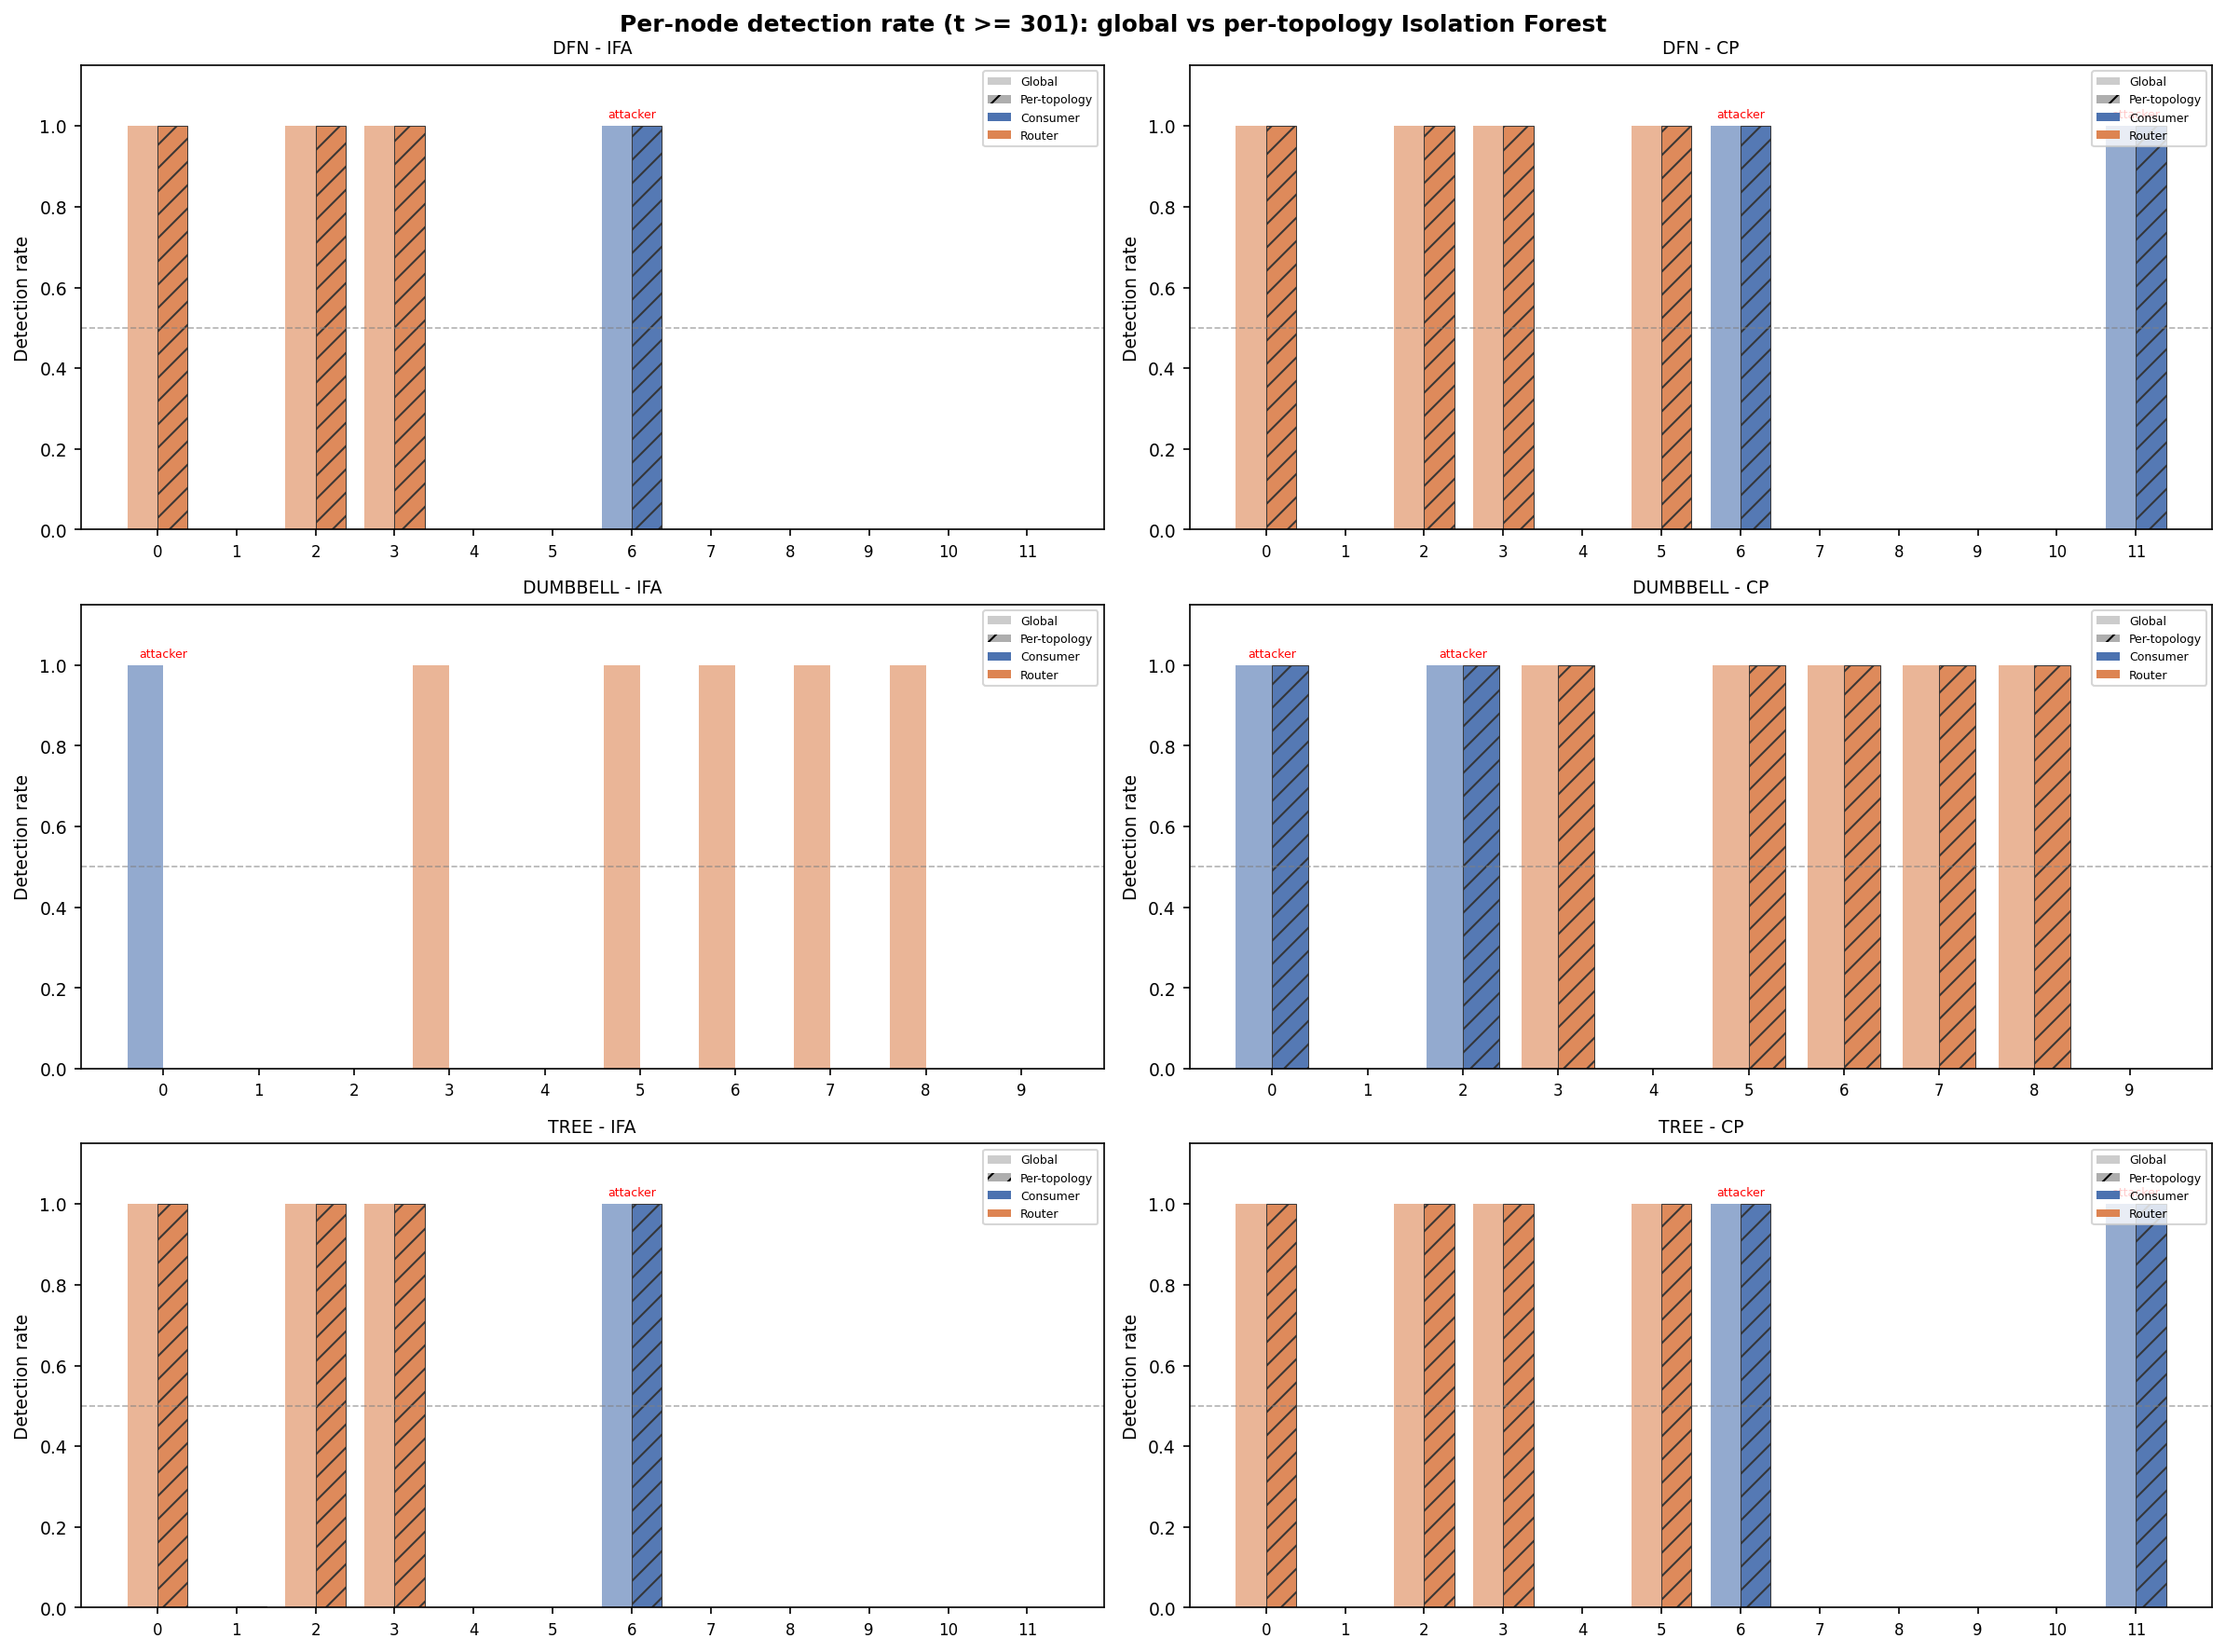

Saved fig_pernode_detection_comparison.png


In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("Per-node detection rate (t >= 301): global vs per-topology Isolation Forest",
             fontsize=12, fontweight="bold")
for row, topo in enumerate(TOPOLOGIES):
    nodes = sorted(full[full["topology"] == topo]["Node"].unique())
    roles = full[full["topology"] == topo].groupby("Node")["role"].first()
    x = np.arange(len(nodes)); width = 0.38
    for col, attack in enumerate(["ifa", "cp"]):
        ax  = axes[row][col]
        atk = ATTACKER_NODES[(topo, attack)]
        gr  = pernode_rate(full_scored,  topo, attack)
        pr  = pernode_rate(full_pertopo, topo, attack)
        colors = [ROLE_COLORS[roles[n]] for n in nodes]
        ax.bar(x - width/2, [gr.get(n, 0) for n in nodes], width, color=colors, alpha=0.6, label="Global")
        ax.bar(x + width/2, [pr.get(n, 0) for n in nodes], width, color=colors, alpha=0.95,
               hatch="//", edgecolor="#333", linewidth=0.5, label="Per-topology")
        for i, n in enumerate(nodes):
            if n in atk:
                ax.annotate("attacker", (i, 1.02), ha="center", fontsize=6, color="red", rotation=0)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.set_xticks(x); ax.set_xticklabels(nodes, fontsize=8)
        ax.set_ylim(0, 1.15); ax.set_ylabel("Detection rate")
        ax.set_title(f"{topo.upper()} - {attack.upper()}", fontsize=9)
        ax.legend(handles=[Patch(facecolor="#aaa", alpha=0.6, label="Global"),
                           Patch(facecolor="#aaa", alpha=0.95, hatch="//", label="Per-topology"),
                           Patch(facecolor=ROLE_COLORS["consumer"], label="Consumer"),
                           Patch(facecolor=ROLE_COLORS["router"], label="Router")],
                  fontsize=6, loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_pernode_detection_comparison.png", bbox_inches="tight")
plt.show()
print("Saved fig_pernode_detection_comparison.png")

## 5. Anomaly score over time

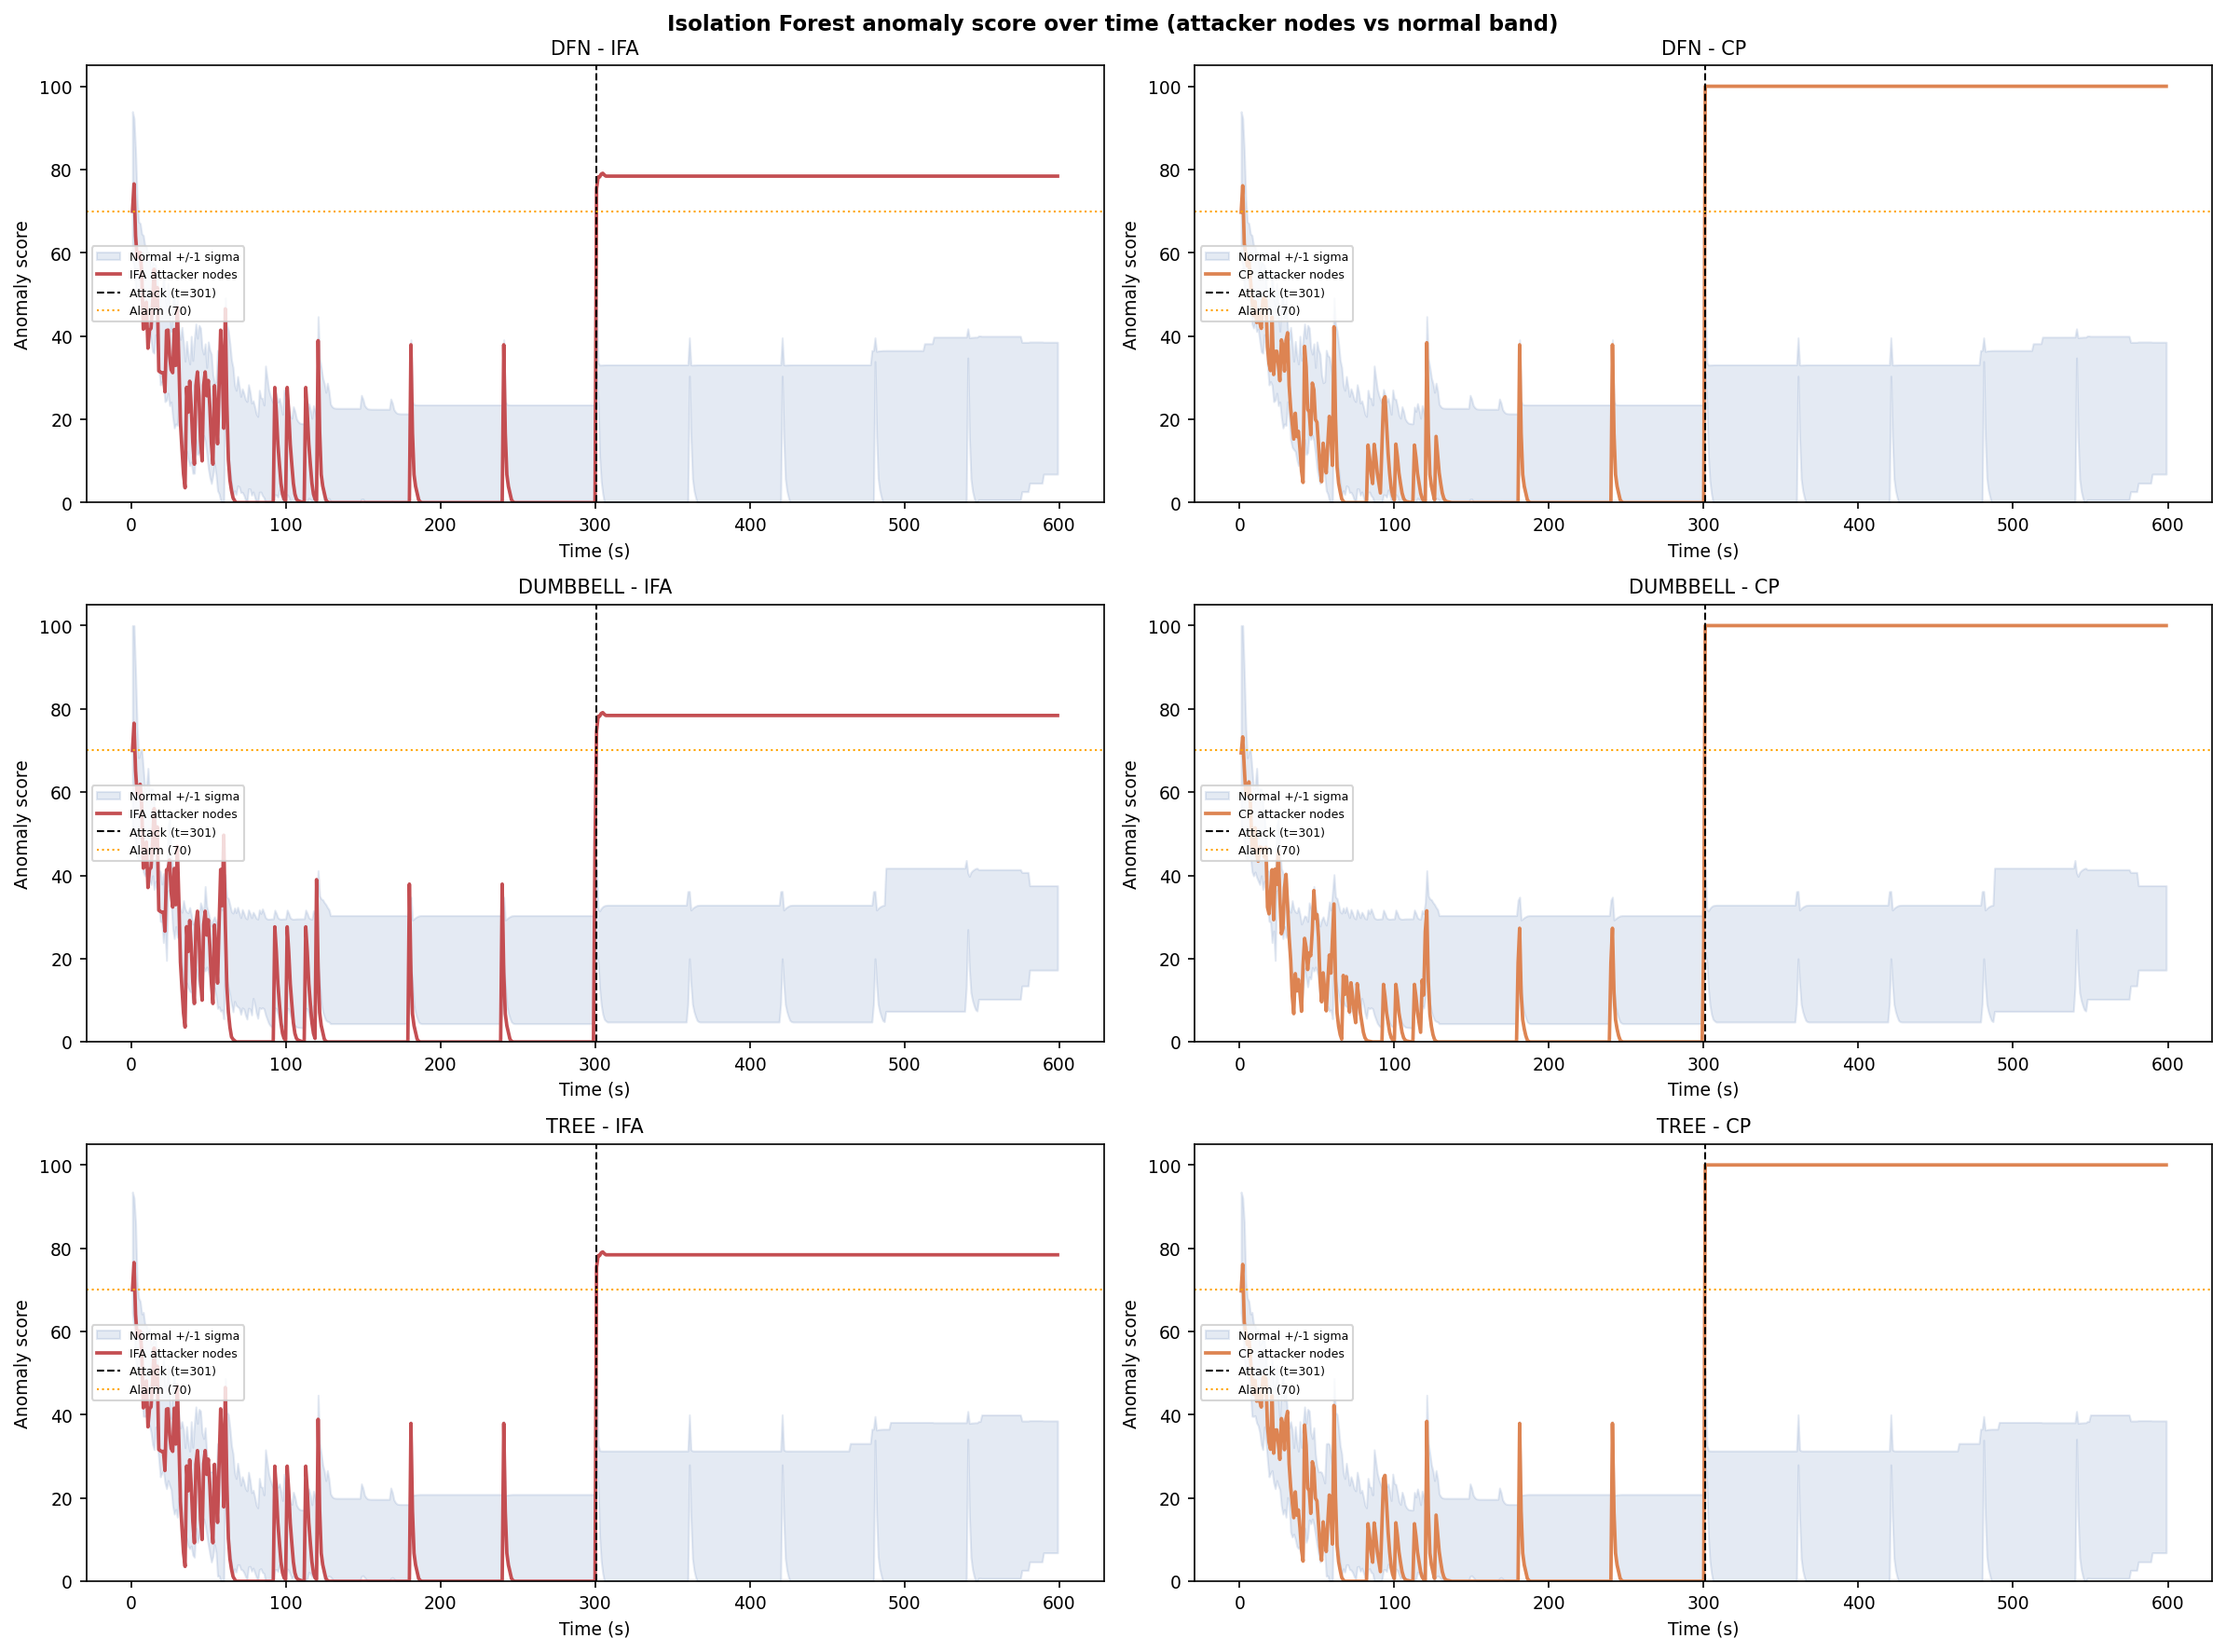

Saved fig_score_timeseries.png


In [8]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for row, topo in enumerate(TOPOLOGIES):
    for col, attack in enumerate(["ifa", "cp"]):
        ax  = axes[row][col]
        atk = ATTACKER_NODES[(topo, attack)]
        # attacker-node mean score
        a_ts = full_scored[(full_scored["topology"] == topo) & (full_scored["scenario"] == attack)
                           & full_scored["Node"].isin(atk)].groupby("Time")["anomaly_score"].mean()
        # normal band (all nodes, normal scenario)
        n_grp = full_scored[(full_scored["topology"] == topo) & (full_scored["scenario"] == "normal")
                            ].groupby("Time")["anomaly_score"]
        n_mean = n_grp.mean(); n_std = n_grp.std().fillna(0)
        ax.fill_between(n_mean.index, (n_mean - n_std).clip(0), (n_mean + n_std).clip(0, 100),
                        alpha=0.15, color=SCENARIO_COLORS["normal"], label="Normal +/-1 sigma")
        ax.plot(a_ts.index, a_ts.values, color=SCENARIO_COLORS[attack], linewidth=1.8,
                label=f"{attack.upper()} attacker nodes")
        ax.axvline(ATTACK_START, color="black", linestyle="--", linewidth=1.0, label=f"Attack (t={ATTACK_START})")
        ax.axhline(ALARM, color="orange", linestyle=":", linewidth=1.0, label=f"Alarm ({ALARM})")
        ax.set_title(f"{topo.upper()} - {attack.upper()}", fontsize=10)
        ax.set_ylim(0, 105); ax.set_xlabel("Time (s)"); ax.set_ylabel("Anomaly score")
        ax.legend(fontsize=6, loc="center left")
fig.suptitle("Isolation Forest anomaly score over time (attacker nodes vs normal band)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_score_timeseries.png", bbox_inches="tight")
plt.show()
print("Saved fig_score_timeseries.png")

## 6. Detection latency

Attacker-node detection (global IF):
        detected_rate  mean_latency_s  n
attack                                  
cp                1.0             1.0  6
ifa               1.0             1.0  3

Saved detection_latency.csv


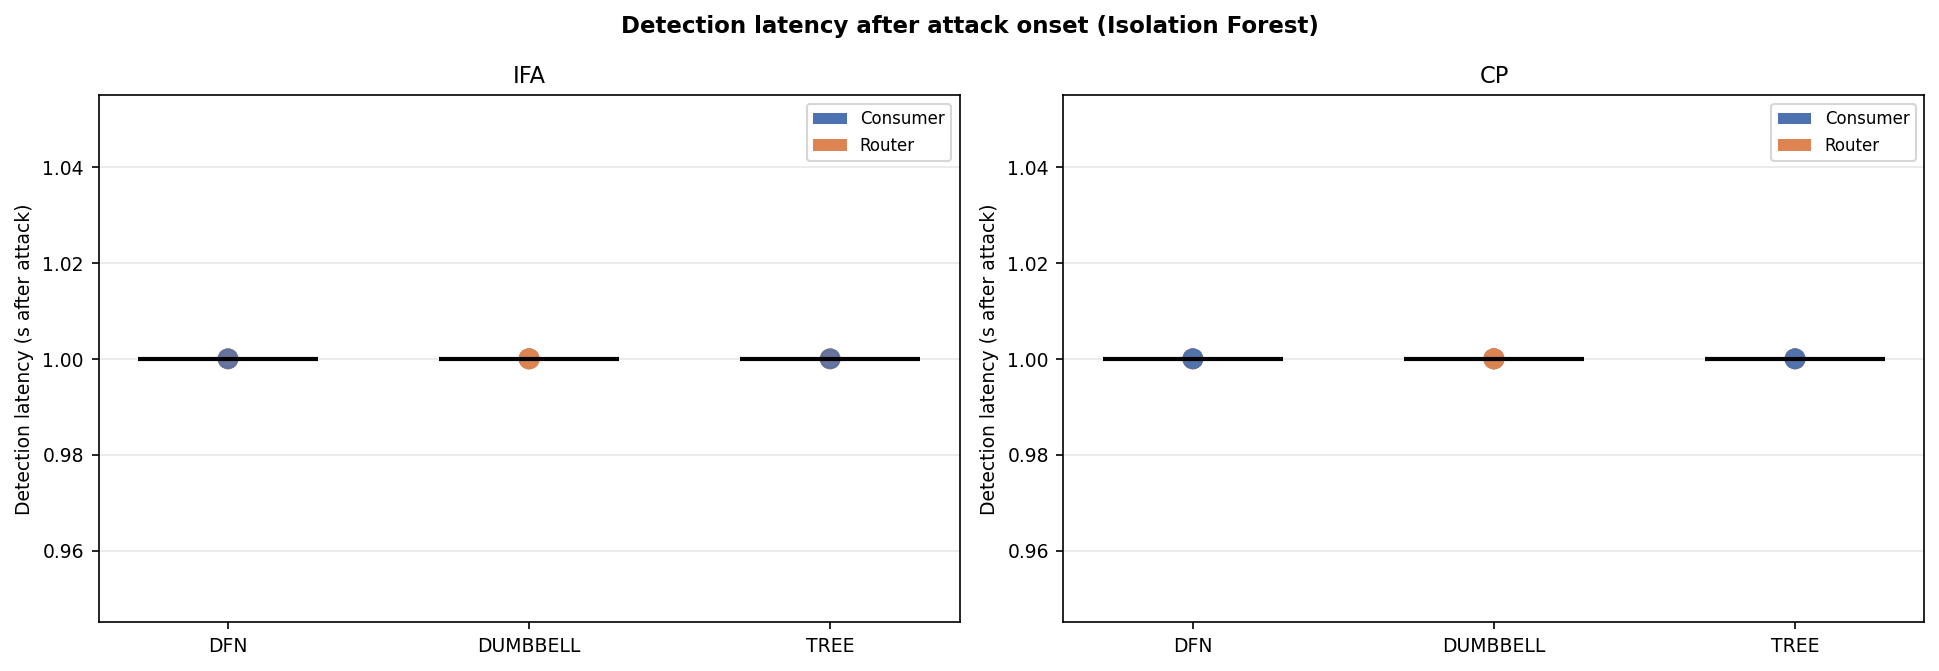

Saved fig_detection_latency.png


In [9]:
def sustained_first(times, flags, k=2, w=3):
    # first time index where >= k of the last w seconds are flagged
    s = pd.Series(flags.astype(int)).rolling(w, min_periods=1).sum().values
    hit = np.where(s >= k)[0]
    return int(times[hit[0]]) if len(hit) else None

lat_rows = []
for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        atk = ATTACKER_NODES[(topo, attack)]
        for node, g in full_scored[(full_scored["topology"] == topo) &
                                   (full_scored["scenario"] == attack)].groupby("Node"):
            g = g[g["Time"] >= ATTACK_START].sort_values("Time")
            t0 = sustained_first(g["Time"].values, g["anomaly"].values)
            lat_rows.append({"topology": topo, "attack": attack, "node": int(node),
                             "role": g["role"].iloc[0], "is_attacker": node in atk,
                             "detected": t0 is not None,
                             "latency_s": (t0 - ATTACK_START) if t0 is not None else None})
df_lat = pd.DataFrame(lat_rows)
df_lat.to_csv(PROCESSED_DIR / "detection_latency.csv", index=False)

atkd = df_lat[df_lat["is_attacker"]]
print("Attacker-node detection (global IF):")
print(atkd.groupby("attack").agg(detected_rate=("detected", "mean"),
                                 mean_latency_s=("latency_s", "mean"),
                                 n=("detected", "size")).round(2).to_string())
print("\nSaved detection_latency.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for col, attack in enumerate(["ifa", "cp"]):
    ax = axes[col]
    d  = df_lat[(df_lat["attack"] == attack) & (df_lat["detected"])]
    for ti, topo in enumerate(TOPOLOGIES):
        dt = d[d["topology"] == topo]
        if dt.empty: continue
        ax.scatter([ti] * len(dt), dt["latency_s"],
                   c=[ROLE_COLORS[r] for r in dt["role"]], s=80, alpha=0.8, zorder=3)
        ax.hlines(dt["latency_s"].mean(), ti - 0.3, ti + 0.3, colors="black", linewidth=2, zorder=4)
    ax.set_xticks(range(len(TOPOLOGIES))); ax.set_xticklabels([t.upper() for t in TOPOLOGIES])
    ax.set_ylabel("Detection latency (s after attack)"); ax.set_title(f"{attack.upper()}")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(handles=[Patch(facecolor=ROLE_COLORS["consumer"], label="Consumer"),
                       Patch(facecolor=ROLE_COLORS["router"], label="Router")], fontsize=8)
plt.suptitle("Detection latency after attack onset (Isolation Forest)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_detection_latency.png", bbox_inches="tight")
plt.show()
print("Saved fig_detection_latency.png")

## 7. Score distribution (separability)

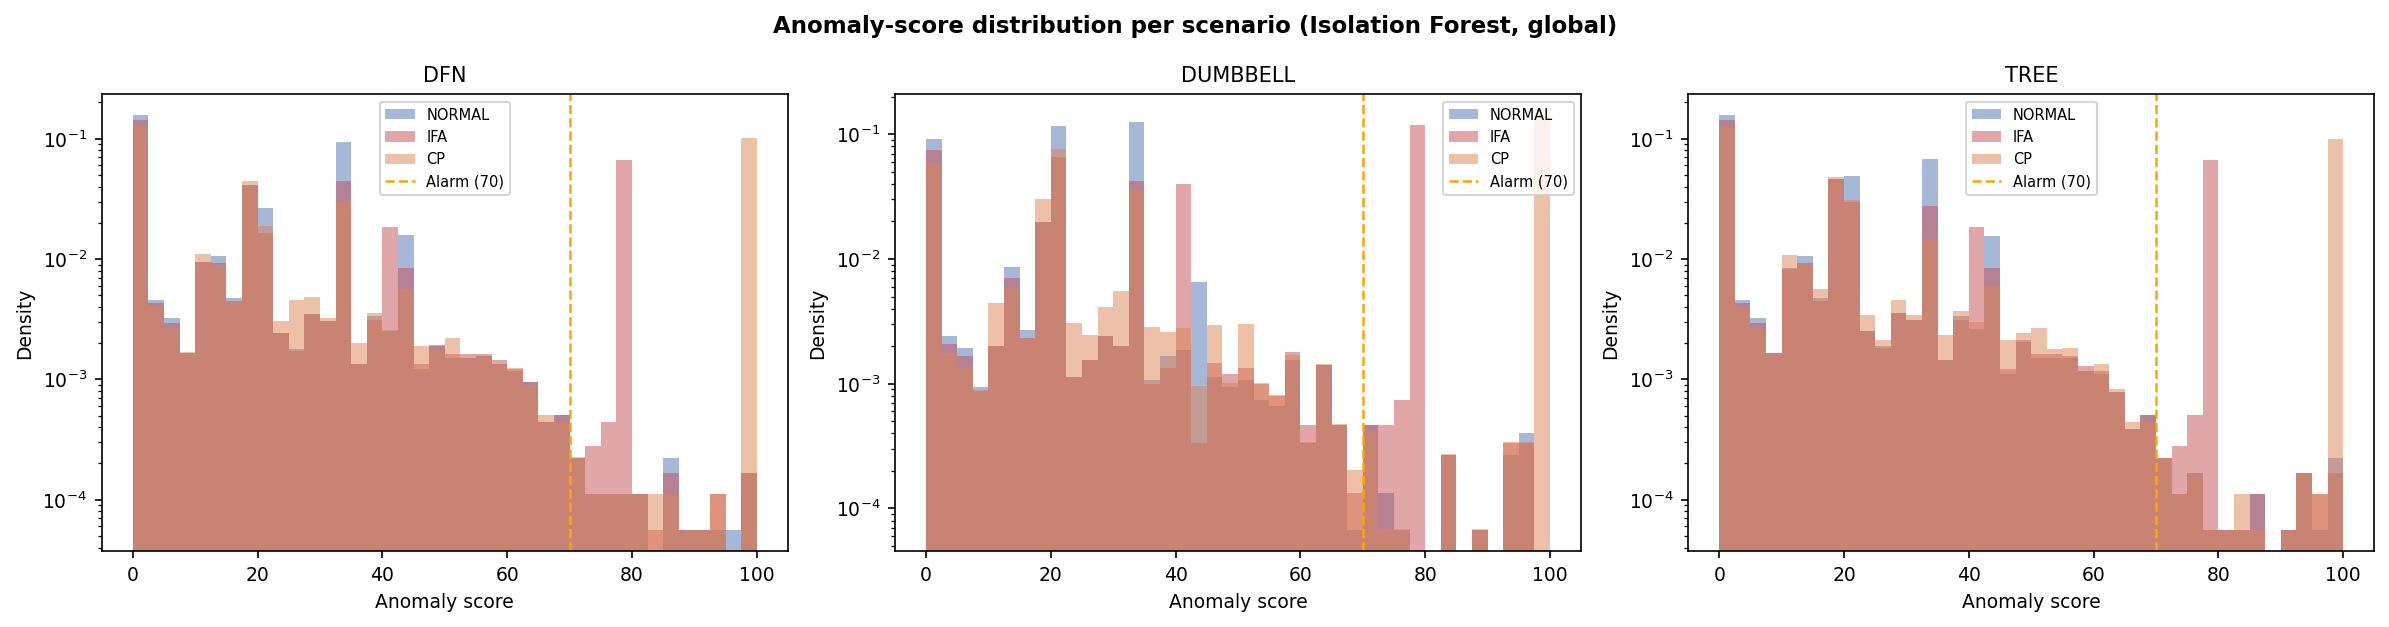

Saved fig_score_dist_comparison.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
bins = np.linspace(0, 100, 41)
for col, topo in enumerate(TOPOLOGIES):
    ax = axes[col]
    for scenario, color in SCENARIO_COLORS.items():
        vals = full_scored[(full_scored["topology"] == topo) &
                           (full_scored["scenario"] == scenario)]["anomaly_score"]
        ax.hist(vals, bins=bins, alpha=0.5, color=color, density=True, label=scenario.upper())
    ax.axvline(ALARM, color="orange", linestyle="--", linewidth=1.2, label=f"Alarm ({ALARM})")
    ax.set_title(f"{topo.upper()}", fontsize=10); ax.set_xlabel("Anomaly score")
    ax.set_ylabel("Density"); ax.set_yscale("log"); ax.legend(fontsize=7)
plt.suptitle("Anomaly-score distribution per scenario (Isolation Forest, global)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_score_dist_comparison.png", bbox_inches="tight")
plt.show()
print("Saved fig_score_dist_comparison.png")

## 8. Validation - robustness and feature ablation

Confirms the detector is not a lucky seed or feature artifact: it is stable
across random seeds and across the global/per-topology choice, and the ablation
shows the rate/count features (which carry attack magnitude) are what make it
work - ratios alone are insufficient.

ROBUSTNESS (full features):
  variant                attackerDet%  benignFA%  normFPR%


  global seed=42                100.0        0.0      0.00


  global seed=1                 100.0        0.0      0.00


  global seed=7                 100.0        0.0      0.00


  per-topology seed=42           88.9        0.0      0.00

FEATURE ABLATION (global, seed=42):


  full (9)                      100.0        0.0      0.00


  counts only                   100.0        0.0      0.00


  ratios only                     0.0        0.0      0.66


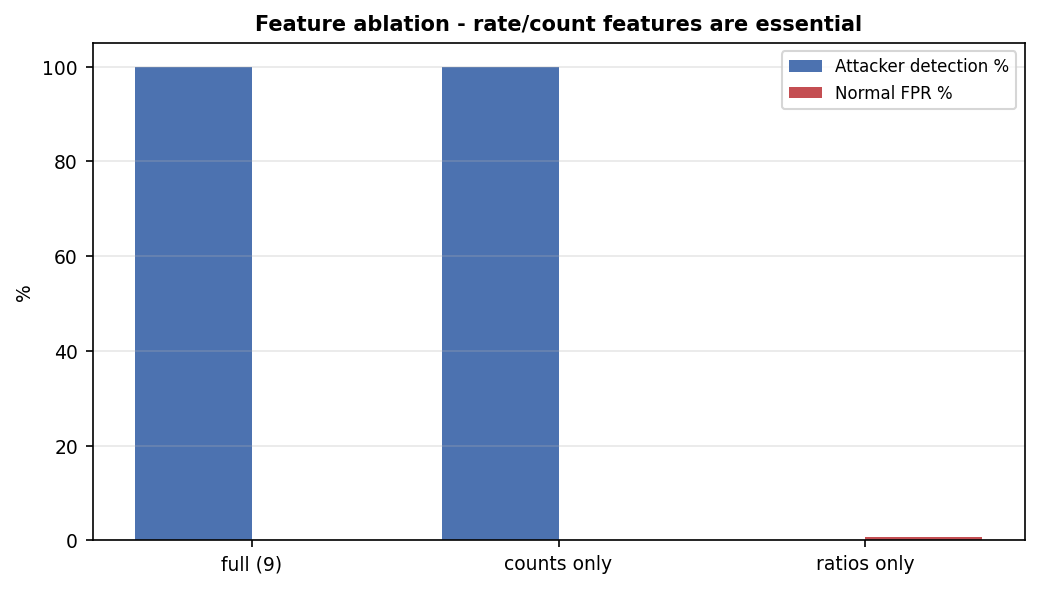

Saved fig_feature_ablation.png


In [11]:
def quick_eval(features, seed, per_topo=False):
    if per_topo:
        ps = []
        for topo in TOPOLOGIES:
            tr = full[(full["topology"] == topo) & (full["scenario"] == "normal") & (full["Time"] <= BASELINE_WINDOW)]
            pipe, smn, smx = fit_if(tr, features, seed)
            ps.append(score_with(pipe, smn, smx, full[full["topology"] == topo], features))
        sc = pd.concat(ps, ignore_index=True)
    else:
        tr = full[(full["scenario"] == "normal") & (full["Time"] <= BASELINE_WINDOW)]
        pipe, smn, smx = fit_if(tr, features, seed)
        sc = score_with(pipe, smn, smx, full, features)
    adet, bfa = [], []
    for topo in TOPOLOGIES:
        for attack in ["ifa", "cp"]:
            atk = ATTACKER_NODES[(topo, attack)]
            g = sc[(sc["topology"] == topo) & (sc["scenario"] == attack) & (sc["Time"] >= ATTACK_START)]
            for node, nd in g.groupby("Node"):
                frac = nd["anomaly"].mean()
                if node in atk: adet.append(frac > 0.5)
                elif nd["role"].iloc[0] == "consumer": bfa.append(frac > 0.5)
    nf = sc[(sc["scenario"] == "normal") & (sc["Time"] > BASELINE_WINDOW)]["anomaly"].mean()
    return 100 * np.mean(adet), 100 * np.mean(bfa), 100 * nf

print("ROBUSTNESS (full features):")
print(f"  {'variant':<22} {'attackerDet%':>12} {'benignFA%':>10} {'normFPR%':>9}")
for seed in [42, 1, 7]:
    a, b, n = quick_eval(FEATURES, seed, per_topo=False)
    print(f"  {'global seed=' + str(seed):<22} {a:>12.1f} {b:>10.1f} {n:>9.2f}")
a, b, n = quick_eval(FEATURES, 42, per_topo=True)
print(f"  {'per-topology seed=42':<22} {a:>12.1f} {b:>10.1f} {n:>9.2f}")

print("\nFEATURE ABLATION (global, seed=42):")
ablate = {"full (9)": FEATURES,
          "counts only": ["InInterests", "OutInterests", "InData"],
          "ratios only": ["cache_hit_ratio", "satisfaction_ratio", "timeout_ratio", "nack_ratio"]}
abl_res = {}
for name, feats in ablate.items():
    a, b, n = quick_eval(feats, 42)
    abl_res[name] = (a, b, n)
    print(f"  {name:<22} {a:>12.1f} {b:>10.1f} {n:>9.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
names = list(abl_res); x = np.arange(len(names)); w = 0.38
ax.bar(x - w/2, [abl_res[k][0] for k in names], w, color="#4c72b0", label="Attacker detection %")
ax.bar(x + w/2, [abl_res[k][2] for k in names], w, color="#c44e52", label="Normal FPR %")
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel("%")
ax.set_title("Feature ablation - rate/count features are essential", fontsize=10, fontweight="bold")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_feature_ablation.png", bbox_inches="tight")
plt.show()
print("Saved fig_feature_ablation.png")

In [12]:
full_scored.to_csv(PROCESSED_DIR / "full_scored_global.csv", index=False)
full_pertopo.to_csv(PROCESSED_DIR / "full_scored_pertopo.csv", index=False)
print("Saved full_scored_global.csv, full_scored_pertopo.csv")

print("\n" + "=" * 70)
print("METHOD: unsupervised Isolation Forest (unified with miniNDN track)")
print(f"  Pipeline   : StandardScaler -> IsolationForest(n_estimators=200, contamination=0.01)")
print(f"  Features   : {FEATURES}")
print(f"  Training   : normal scenario only, first {BASELINE_WINDOW}s (no labels in fitting)")
print(f"  Score      : anomaly_score = 100 - normalized decision_function (high = anomalous)")
print(f"  Alarm      : anomaly_score >= {ALARM}")
print(f"  Labels     : evaluation only (detection rate / latency / FPR)")
print("=" * 70)

Saved full_scored_global.csv, full_scored_pertopo.csv

METHOD: unsupervised Isolation Forest (unified with miniNDN track)
  Pipeline   : StandardScaler -> IsolationForest(n_estimators=200, contamination=0.01)
  Features   : ['InInterests', 'OutInterests', 'InData', 'cache_hit_ratio', 'satisfaction_ratio', 'timeout_ratio', 'nack_ratio', 'interest_amp', 'data_ratio']
  Training   : normal scenario only, first 200s (no labels in fitting)
  Score      : anomaly_score = 100 - normalized decision_function (high = anomalous)
  Alarm      : anomaly_score >= 70
  Labels     : evaluation only (detection rate / latency / FPR)


## 9. Conclusion

A single unsupervised Isolation Forest - the **same method as the miniNDN track** -
detects **both** IFA and CP on ndnSIM telemetry: every attacker node is flagged,
benign consumers are not, on-path routers light up (spatial localization), and the
held-out normal-traffic false-positive rate is near zero. The result is stable
across seeds and across the global / per-topology choice. This unifies the whole
study under one detector and removes the need for any attack-specific,
hand-tuned detector.